In [1]:
#import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

# data (as pandas dataframes)
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

# metadata
print(statlog_german_credit_data.metadata)

# variable information
print(statlog_german_credit_data.variables)


{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

**EDA**

Text(0.5, 1.0, 'Employment Stability Trends across Checking Account Status')

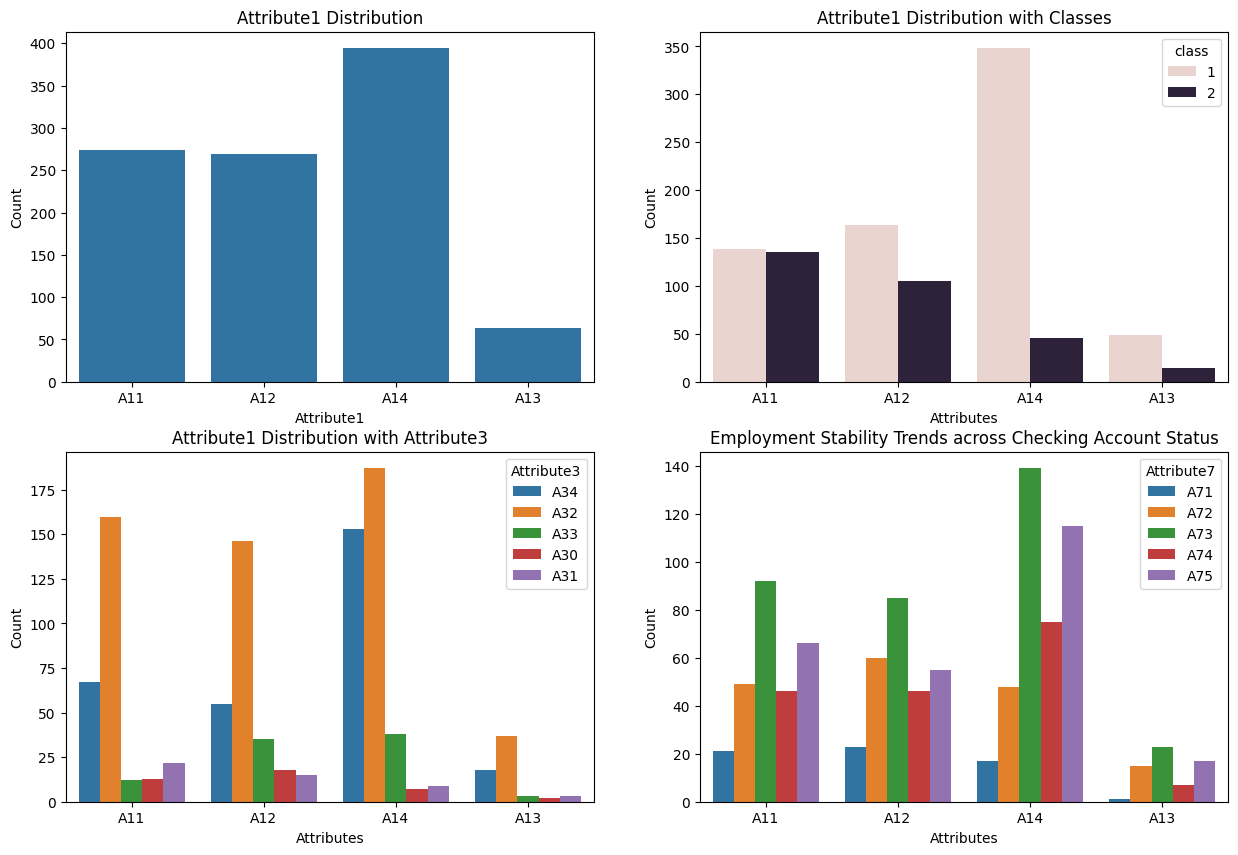

<Figure size 1000x600 with 0 Axes>

In [3]:
# Attribute 1 Distribution
fig, ax = plt.subplots(2, 2, figsize = (15, 10))
ax = ax.flatten()
sns.countplot(data = X, x = 'Attribute1', ax = ax[0])
ax[0].set_xlabel('Attribute1')
ax[0].set_ylabel('Count')
ax[0].set_title('Attribute1 Distribution')

# Figure 2
sns.countplot(data = X, x = 'Attribute1', hue = y['class'], ax = ax[1])
ax[1].set_xlabel('Attributes')
ax[1].set_ylabel('Count')
ax[1].set_title('Attribute1 Distribution with Classes')

#Figure 3
sns.countplot(data = X, x = 'Attribute1', hue = X['Attribute3'], ax = ax[2])
ax[2].set_xlabel('Attributes')
ax[2].set_ylabel('Count')
ax[2].set_title('Attribute1 Distribution with Attribute3')

# Figure 4
employment_order = ['A71', 'A72', 'A73', 'A74', 'A75']

plt.figure(figsize=(10, 6))
sns.countplot(
    data=X,
    x='Attribute1',
    hue='Attribute7',
    order=['A11', 'A12', 'A14', 'A13'], # Ordering X-axis
    hue_order=employment_order, # Ordering the Legend (Hue)
    ax = ax[3]
    )

ax[3].set_xlabel('Attributes')
ax[3].set_ylabel('Count')
ax[3].set_title('Employment Stability Trends across Checking Account Status')


Text(0.5, 1.0, 'Credit Duration History with Classes')

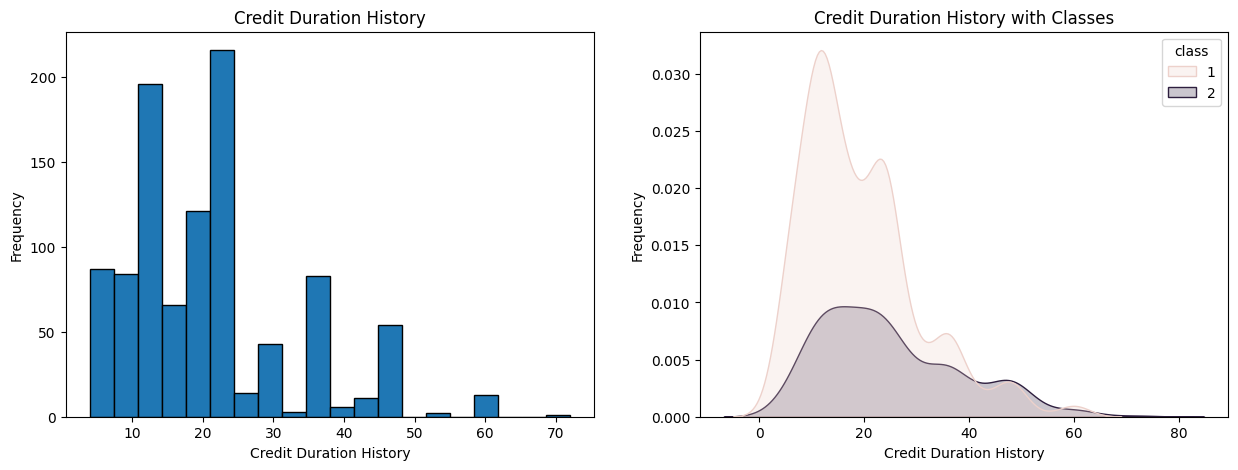

In [4]:
from seaborn.distributions import kdeplot
# Distribution of credit duration history
fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ax = ax.flatten()
ax[0].hist(X['Attribute2'], bins = 20, edgecolor = 'black')
ax[0].set_xlabel('Credit Duration History')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Credit Duration History')

# Distribution of credit duration according to class
sns.kdeplot(data = X, x = 'Attribute2', hue = y['class'],fill = True, ax = ax[1])
ax[1].set_xlabel('Credit Duration History')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Credit Duration History with Classes')

In [5]:
# Feature engineering

#binning the credit duration as they have unseparable distribution
bins = [0,12, 30, X['Attribute2'].max()]
labels = ['Short', 'Medium', 'Long']
X['duration_category'] = pd.cut(X['Attribute2'], bins = bins, labels = labels)



<Figure size 1000x600 with 0 Axes>

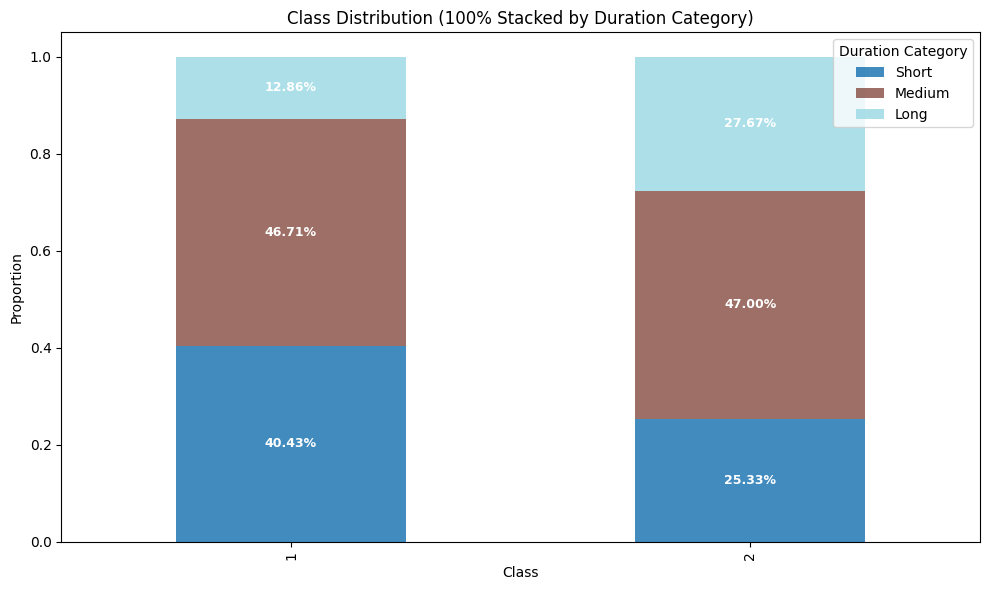

In [6]:
df = pd.concat([X, y], axis = 1)
plt.figure(figsize=(10, 6))

proportions = (
    df.groupby('class')['duration_category']
      .value_counts(normalize=True)
      .unstack('duration_category')
)

# Plot stacked bar chart
ax = proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20',
    alpha=0.85
)

plt.xlabel('Class')
plt.ylabel('Proportion')
plt.title('Class Distribution (100% Stacked by Duration Category)')
plt.legend(title='Duration Category', loc='upper right')
plt.tight_layout()

# Annotation
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  x, y = p.get_xy()
  if height > 0:
    ax.annotate(f'{height:.2%}', (x + width/2, y + height/2), ha='center', va = 'center', fontsize=9, color='white', weight='bold')

plt.show()


Text(0.5, 1.0, 'Purpose of Credit with Age')

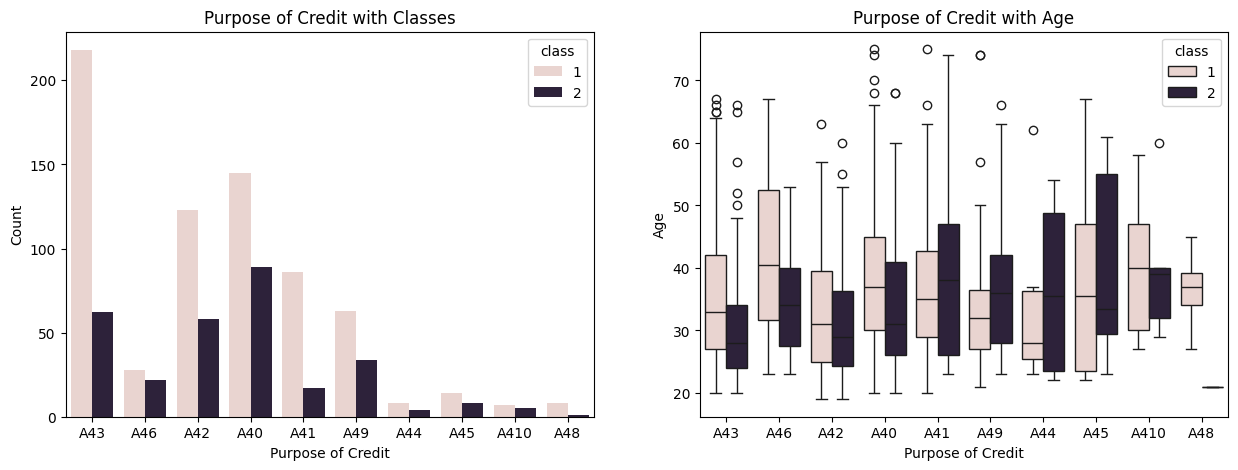

In [7]:
fig, ax = plt.subplots(1, 2, figsize = (15, 5))

# Purpose of credit with class
sns.countplot(data = df, x = 'Attribute4', hue = 'class', ax = ax[0])
ax[0].set_xlabel('Purpose of Credit')
ax[0].set_ylabel('Count')
ax[0].set_title('Purpose of Credit with Classes')

# comparing the purpose of credit with age
sns.boxplot(data = df, x = 'Attribute4', y = 'Attribute13', hue = 'class',ax = ax[1])
ax[1].set_xlabel('Purpose of Credit')
ax[1].set_ylabel('Age')
ax[1].set_title('Purpose of Credit with Age')

Text(0.5, 1.0, 'Personal Status with Housing')

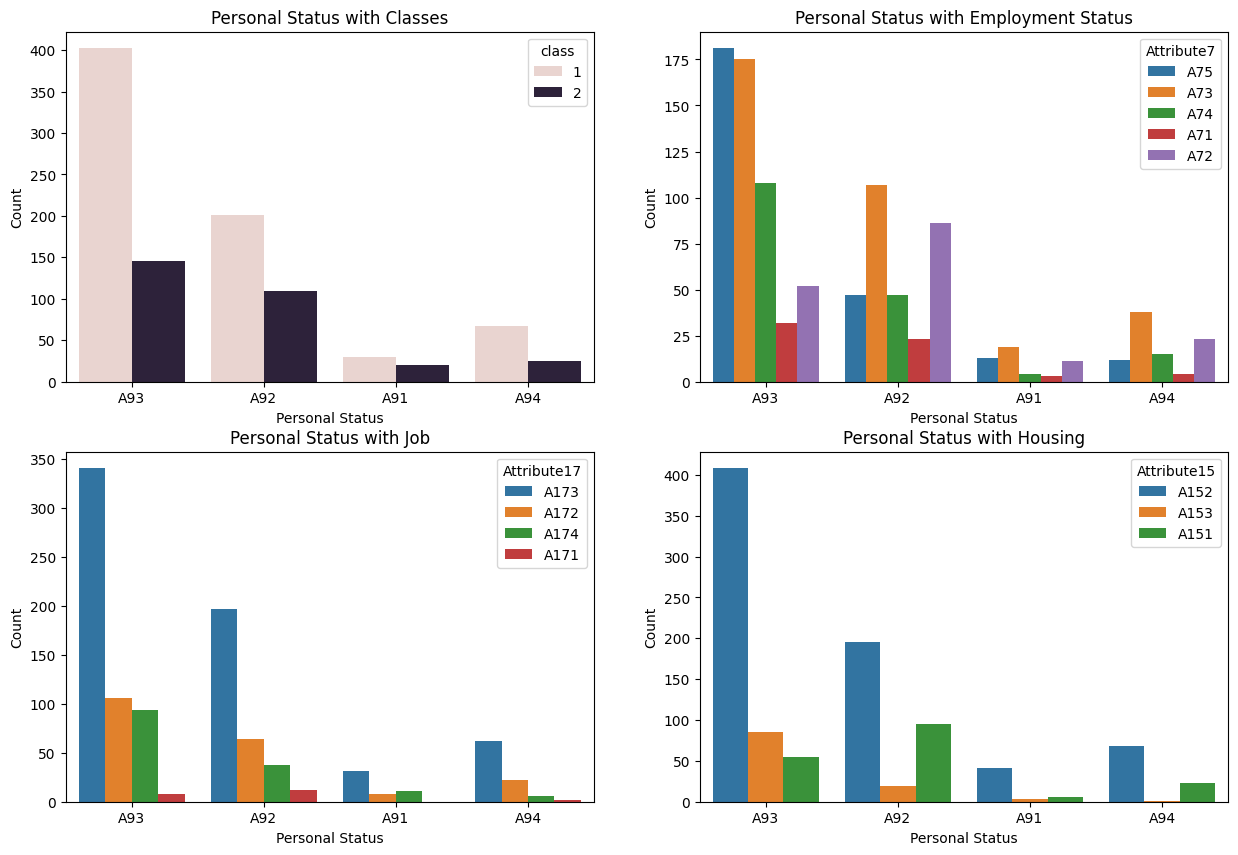

In [8]:
#Personal Status
fig, ax = plt.subplots(2,2,figsize = (15, 10))
ax = ax.flatten()
sns.countplot(data = df, x = 'Attribute9', hue = 'class', ax = ax[0])
ax[0].set_xlabel('Personal Status')
ax[0].set_ylabel('Count')
ax[0].set_title('Personal Status with Classes')

sns.countplot(data = df, x = 'Attribute9', hue = 'Attribute7', ax = ax[1])
ax[1].set_xlabel('Personal Status')
ax[1].set_ylabel('Count')
ax[1].set_title('Personal Status with Employment Status')

sns.countplot(data = df, x = 'Attribute9', hue = 'Attribute17', ax = ax[2])
ax[2].set_xlabel('Personal Status')
ax[2].set_ylabel('Count')
ax[2].set_title('Personal Status with Job')

sns.countplot(data = df, x = 'Attribute9', hue = 'Attribute15', ax = ax[3])
ax[3].set_xlabel('Personal Status')
ax[3].set_ylabel('Count')
ax[3].set_title('Personal Status with Housing')

Text(0.5, 1.0, 'Personal Status with No of liable maintenance')

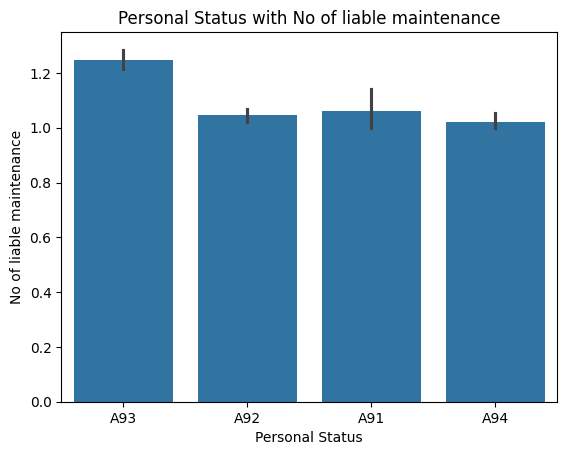

In [9]:
sns.barplot(data = df, x = 'Attribute9', y = 'Attribute18')
plt.xlabel('Personal Status')
plt.ylabel('No of liable maintenance')
plt.title('Personal Status with No of liable maintenance')

In [10]:
# outliers detections
num_features = X.select_dtypes(include = ['int64', 'float64']).columns

def cap_features(df, features):
  for feature in features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    df[feature] = df[feature].clip(upper = upper_bound)

  return df

df = cap_features(df, num_features)
df = cap_features(df, ['Attribute13'])

In [11]:
from scipy.stats import chi2_contingency

def chi_square_test(df, feature1, feature2):
  cong_table = pd.crosstab(df[feature1], df[feature2])
  chi2, p, dof, expected = chi2_contingency(cong_table)

  if p < 0.05:
    print(f'Reject the Null Hypothesis: There is significant association between {feature1}and {feature2}')
  else:
    print(f'Fail to reject the Null Hypothesis: There is no significant association between {feature1} and {feature2} ')

chi_square_test(df, 'Attribute1', 'Attribute3')
chi_square_test(df, 'Attribute1', 'Attribute7')
chi_square_test(df, 'Attribute9', 'Attribute7')
chi_square_test(df, 'Attribute9', 'Attribute17')
chi_square_test(df, 'Attribute9', 'Attribute15')
chi_square_test(df, 'Attribute9', 'Attribute18')


Reject the Null Hypothesis: There is significant association between Attribute1and Attribute3
Reject the Null Hypothesis: There is significant association between Attribute1and Attribute7
Reject the Null Hypothesis: There is significant association between Attribute9and Attribute7
Reject the Null Hypothesis: There is significant association between Attribute9and Attribute17
Reject the Null Hypothesis: There is significant association between Attribute9and Attribute15
Fail to reject the Null Hypothesis: There is no significant association between Attribute9 and Attribute18 


In [12]:
# Encoding the categorical values
from sklearn.preprocessing import LabelEncoder

ordinal_mappings = {
    'Attribute1':{'A11':0, 'A12':1, 'A13':2, 'A14':3},
    'Attribute3':{'A30':1, 'A31':3, 'A32':3, 'A33':0, 'A34':4},
    'Attribute6':{'A61':0,'A65': 1, 'A62':2, 'A63':3, 'A64':4 },
    'Attribute7':{'A71':0, 'A72':1, 'A73':2, 'A74':3, 'A75':4},
    'Attribute17': {'A171':0, 'A172':1, 'A173':2, 'A174':3},
    'duration_category':{'Short':0, 'Medium':1, 'Long':2}
}

le = LabelEncoder()
attr = [4,9,10,12,14,15,19,20]

for i in attr:
  df[f'Attribute{i}'] = le.fit_transform(df[f'Attribute{i}'])

for feature, mapping in ordinal_mappings.items():
  df[feature] = df[feature].map(mapping)

In [13]:
df['duration_category'] = df['duration_category'].astype('int64')
df.drop('Attribute2', axis = 1, inplace = True) # binned


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score
from sklearn.tree import DecisionTreeClassifier

def run_model(features, title):

  X = df[features]
  y = df['class']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

  clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    ccp_alpha=0.01
)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  cm = confusion_matrix(y_test, y_pred, labels = [1,2])
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
  disp.plot(cmap=plt.cm.Blues)
  plt.title(f"Confusion Matrix :{title}")
  plt.show()
  print(f"F1-score:{f1_score(y_test, y_pred):2f}")
  print(f"Recall:{recall_score(y_test, y_pred, pos_label = 2):2f}")

  return clf, X_test




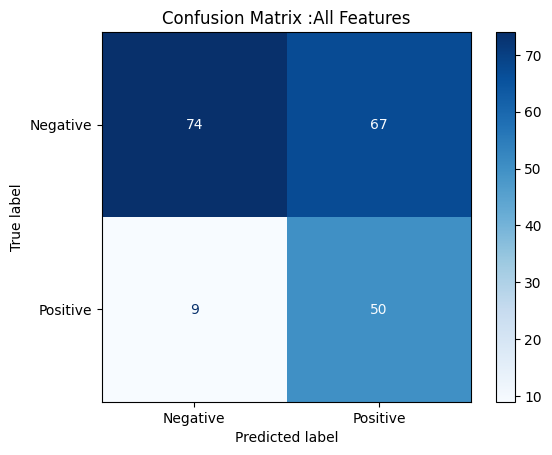

F1-score:0.660714
Recall:0.847458


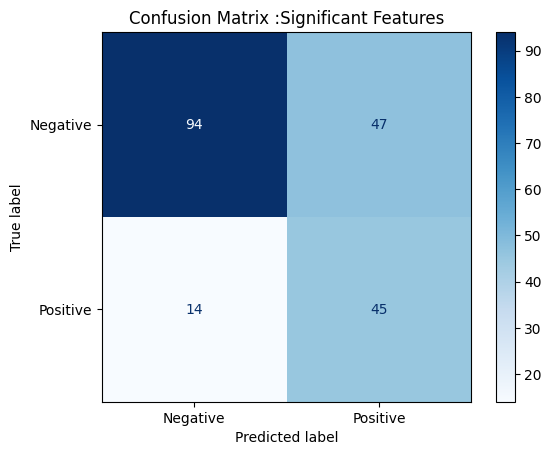

F1-score:0.755020
Recall:0.762712


In [15]:
feature_col = [col for col in df.columns if col != 'class']
clf, X_test = run_model(feature_col, 'All Features')
sig_features = ['Attribute1', 'Attribute3', 'Attribute7', 'Attribute9', 'Attribute17', 'Attribute15', 'duration_category']
clf2, X_test = run_model(sig_features, 'Significant Features')


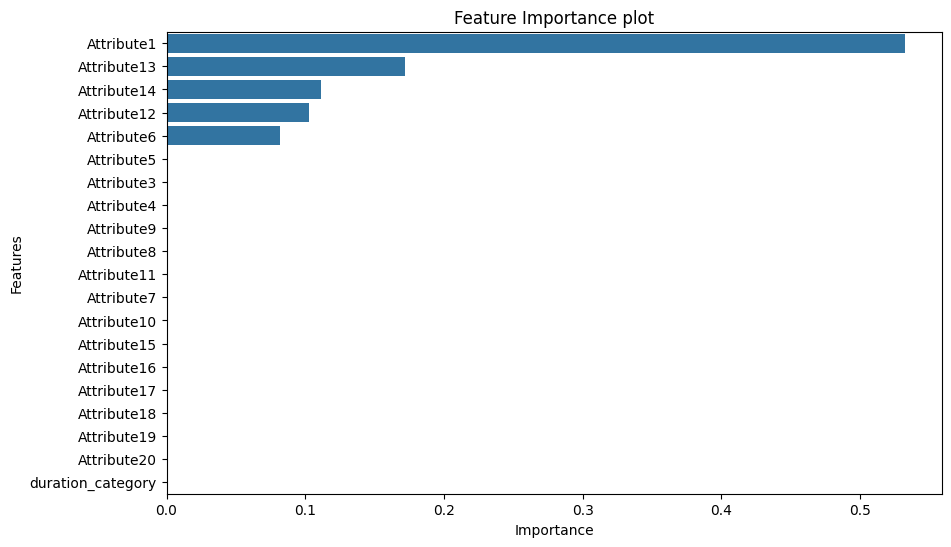

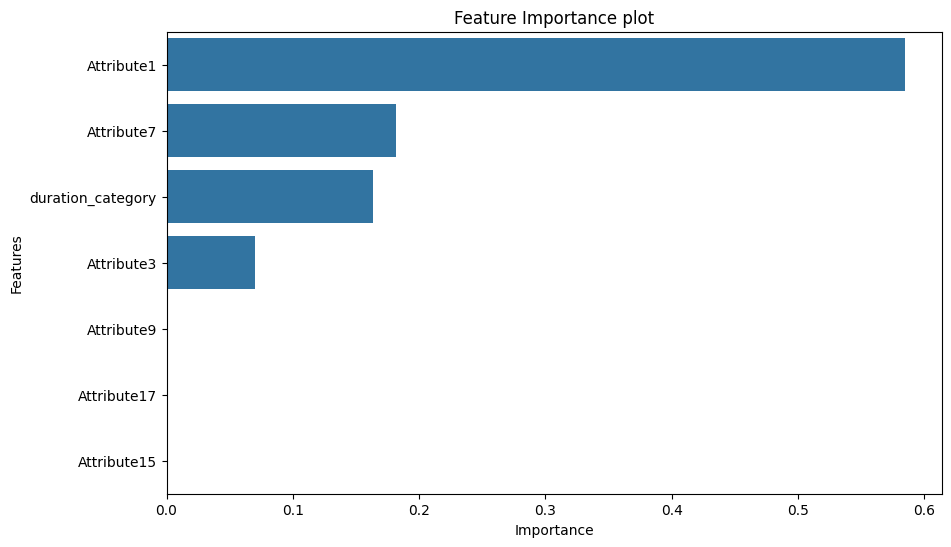

In [16]:
def feature_importance_plot(clf, features):
  imp = clf.feature_importances_
  imp_df = pd.DataFrame({'Features': features, 'Importance': imp})
  imp_df = imp_df.sort_values(by = 'Importance', ascending = False)
  plt.figure(figsize = (10, 6))
  sns.barplot(data = imp_df, x = 'Importance', y = 'Features')
  plt.xlabel('Importance')
  plt.ylabel('Features')
  plt.title('Feature Importance plot')
  plt.show()

feature_importance_plot(clf, feature_col)
feature_importance_plot(clf2, sig_features)

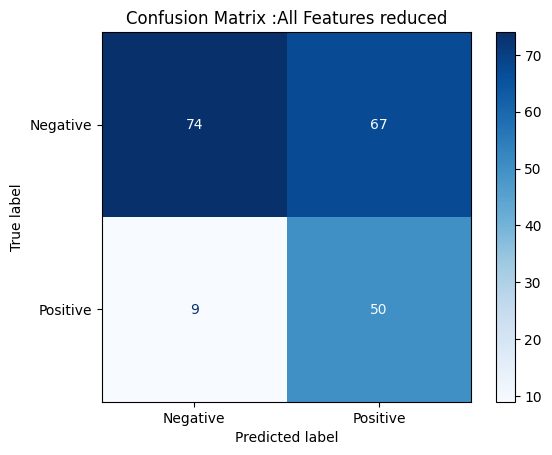

F1-score:0.660714
Recall:0.847458


In [17]:
imp_feat = pd.Series(clf.feature_importances_, index = feature_col).sort_values(ascending = False)
new_feat = [feat for feat in imp_feat.index if imp_feat[feat] > 0]
clf3, X_test = run_model(new_feat, 'All Features reduced')


In [120]:
def shap_plots(clf, X_test_df, row_index, summary_plot = False, waterfall_plot = False):
  explainer = shap.TreeExplainer(clf)
  shap_values = explainer(X_test_df)
  n_classes = len(explainer.expected_value)

  if waterfall_plot:
    for i in range(n_classes):
      class_name = "Bad Risk" if i == 1 else "Good Risk"
      shap.plots.waterfall(shap_values[row_index,:,i], show = False)
      plt.gcf().set_size_inches(8,8)
      plt.title(f"Waterfall Plot: (Class: {class_name})", pad = 20)
      plt.tight_layout(pad = 3.0)
      plt.show()
      print()


  if summary_plot:
    for i in range(n_classes):
      class_name = "Bad Risk" if i == 1 else "Good Risk"
      shap.summary_plot(shap_values[:,:,i], X_test_df, show = False)
      plt.gcf().set_size_inches(8,8)
      plt.title(f"Summary Plot: (Class:{class_name})", pad = 20)
      plt.tight_layout(pad = 3.0)
      plt.show()
      print()



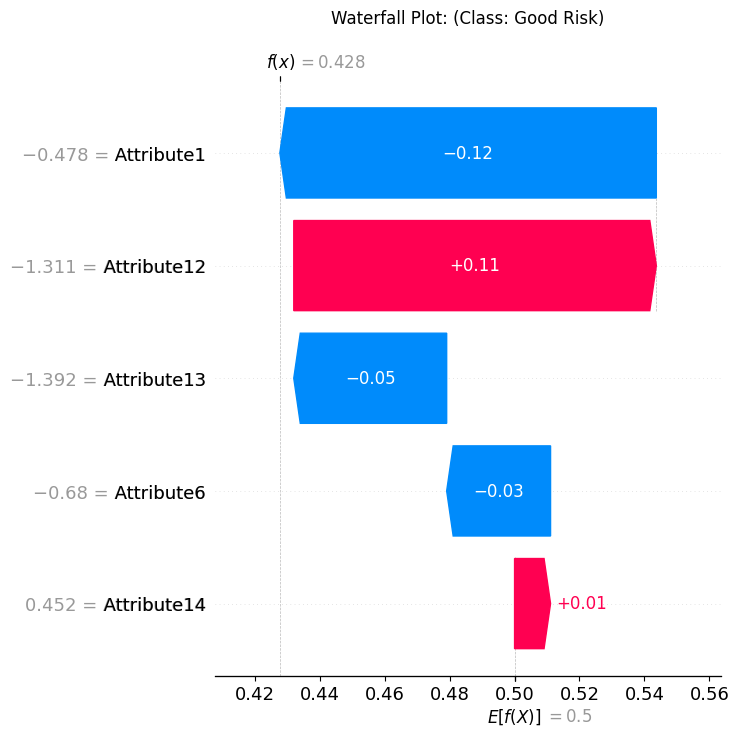

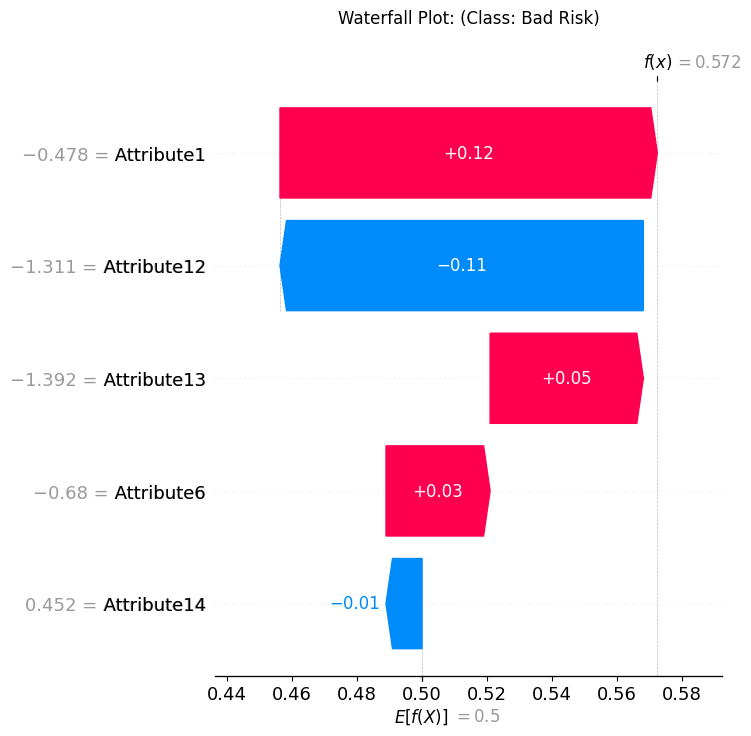

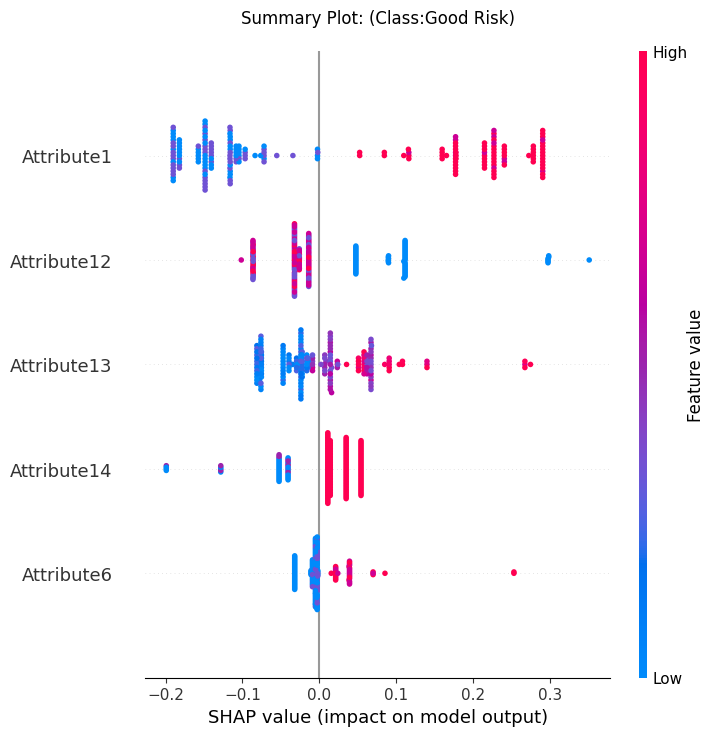

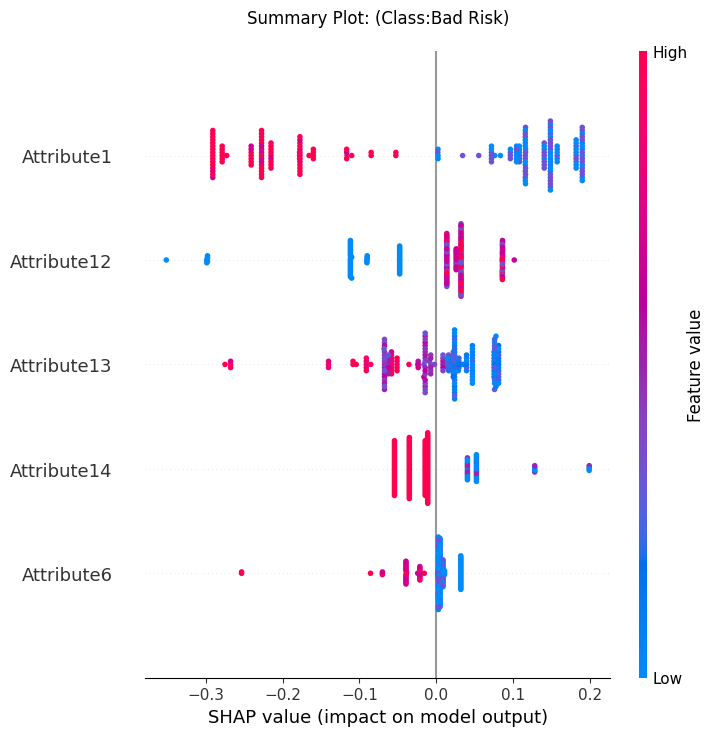

In [121]:
shap_plots(clf3, X_test_df, row_index = 7, waterfall_plot = True, summary_plot = True)